In [1]:
import polars as pl
import numpy as np
from matplotlib import pyplot as plt
from scipy import optimize, integrate


In [2]:
# load in data
simulated_background = np.loadtxt("data/simulated-background.data")
simulated_background = pl.DataFrame(simulated_background,
                                    schema=["p_T1", "phi_1", "eta_1", "p_T2", "phi_2", "eta_2", "effective_mass"])
print(simulated_background.describe())

# restrict range to get a good plot
simulated_background = simulated_background.remove(pl.col("effective_mass") >= 160)

# make cuts in data
simulated_background = simulated_background.remove((pl.col("eta_1") < -2.1) | (pl.col("eta_1") > 2.1))
simulated_background = simulated_background.remove((pl.col("eta_2") < -2.1) | (pl.col("eta_2") > 2.1))
# has to have at least one isolated muon above 24GeV - this has already been done to the data

# check if operations have been performed
print(simulated_background.describe())

shape: (9, 8)
┌────────────┬───────────┬───────────┬───────────┬──────────┬───────────┬───────────┬──────────────┐
│ statistic  ┆ p_T1      ┆ phi_1     ┆ eta_1     ┆ p_T2     ┆ phi_2     ┆ eta_2     ┆ effective_ma │
│ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---      ┆ ---       ┆ ---       ┆ ss           │
│ str        ┆ f64       ┆ f64       ┆ f64       ┆ f64      ┆ f64       ┆ f64       ┆ ---          │
│            ┆           ┆           ┆           ┆          ┆           ┆           ┆ f64          │
╞════════════╪═══════════╪═══════════╪═══════════╪══════════╪═══════════╪═══════════╪══════════════╡
│ count      ┆ 100000.0  ┆ 100000.0  ┆ 100000.0  ┆ 100000.0 ┆ 100000.0  ┆ 100000.0  ┆ 100000.0     │
│ null_count ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0      ┆ 0.0       ┆ 0.0       ┆ 0.0          │
│ mean       ┆ 45.655286 ┆ -0.006056 ┆ -0.000776 ┆ 32.99152 ┆ -0.007381 ┆ -0.002015 ┆ 88.498823    │
│ std        ┆ 11.651188 ┆ 1.813615  ┆ 1.335296  ┆ 9.773493 ┆ 1.815887  ┆ 1.3

Count has reduced. Maximum and minimum values for eta and mass are as they should be.

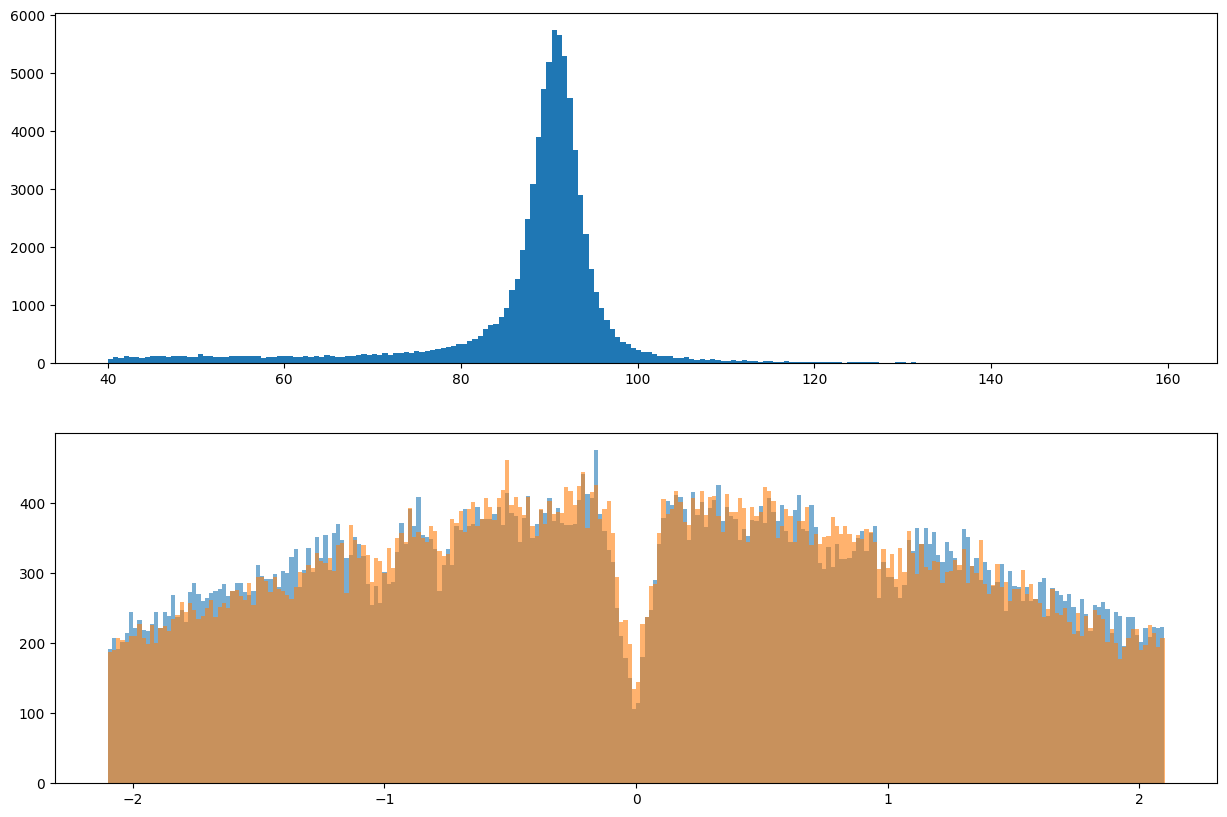

In [3]:
# plot data to make sure it loaded in and cut correctly
mass_hist = simulated_background["effective_mass"].hist(bin_count=200)
bin_width_m = (mass_hist["breakpoint"][1:] - mass_hist["breakpoint"][:-1]).mean()

fig = plt.figure(figsize=(15,10))
ax_dict = fig.subplot_mosaic([["mass"], ["pseudorapidity"]])

# centres of the mass bins = mass_hist["breakpoint"] - (bin_width_m / 2)
ax_dict["mass"].bar(mass_hist["breakpoint"] - (bin_width_m / 2), mass_hist["count"], width=bin_width_m)

pseudorapidity_hist_1 = simulated_background["eta_1"].hist(bin_count=250)
bin_width_eta_1 = (pseudorapidity_hist_1["breakpoint"][1:] - pseudorapidity_hist_1["breakpoint"][:-1]).mean()
# centres of the pseudorapidity bins = pseudorapidity_hist_1["eta_1"] - (bin_width_eta_1 / 2)
ax_dict["pseudorapidity"].bar(pseudorapidity_hist_1["breakpoint"] - (bin_width_eta_1 / 2),
                         pseudorapidity_hist_1["count"], width=bin_width_eta_1, alpha=0.6)

pseudorapidity_hist_2 = simulated_background["eta_2"].hist(bin_count=250)
bin_width_eta_2 = (pseudorapidity_hist_2["breakpoint"][1:] - pseudorapidity_hist_2["breakpoint"][:-1]).mean()
# centres of the pseudorapidity bins = pseudorapidity_hist_1["eta_1"] - (bin_width_eta_1 / 2)
ax_dict["pseudorapidity"].bar(pseudorapidity_hist_2["breakpoint"] - (bin_width_eta_2 / 2),
                         pseudorapidity_hist_2["count"], width=bin_width_eta_2, alpha=0.6)

plt.show()


cuts and restriction worked

Try a modified Breit-Wigner Function:
$$
\mathrm{mBW}(m_{\mu\mu}; m_Z, \Gamma_Z, a_1, a_2, a_3) =
\dfrac{\exp(a_2 m_{\mu\mu} + a_3 m_{\mu\mu}^2)}
      {(m_{\mu\mu} - m_{Z})^{a_1} + \left( \dfrac{\Gamma_Z}{2} \right)^{a_1}}
$$

$m_Z, \Gamma_Z, a_1, a_2, a_3$ are all fitting parameters, with $m_Z$ and $\Gamma_Z$ representing the mass of the Z-boson and the width of the Z-boson, respectively. The values for those should be 91.19 and 2.49

In [4]:
def mBW(m, m_Z, Gamma_Z, a_1, a_2, a_3, const):
    # use exponents and logarithms to deal with very high numbers
    # print(m_Z, Gamma_Z, a_1, a_2, a_3, const)
    return np.exp(const + a_2 * m + a_3 * m**2) / np.exp(a_1*np.log(m - m_Z) + a_1*np.log(Gamma_Z / 2))

C:\Users\karth\OneDrive - University of Birmingham\Documents\Year 2\Data Science Project\.venv\Lib\site-packages\polars\series\series.py:1674: RuntimeWarning: overflow encountered in exp
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),
C:\Users\karth\OneDrive - University of Birmingham\Documents\Year 2\Data Science Project\.venv\Lib\site-packages\polars\series\series.py:1674: RuntimeWarning: invalid value encountered in log
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),


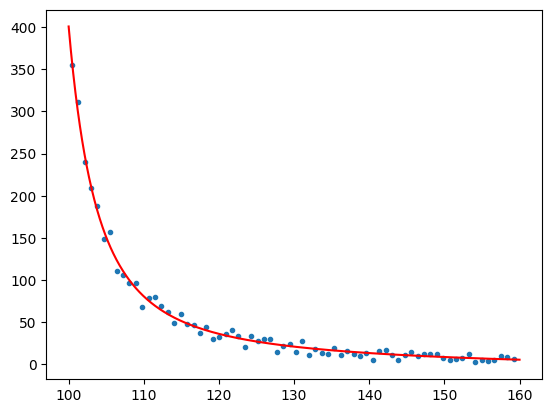

m_Z = 90.50204775377158
Gamma_Z = 0.020041397919579908
a_1 = 2.9699084939391946
a_2 = 0.16227049129851734
a_3 = -0.0005185530755503164
const = -12.03357545757651



In [5]:
# restrict range
lower_bound = 100
upper_bound = 160
restricted_simulated_background = simulated_background.remove(
    (pl.col("effective_mass") < lower_bound) | (pl.col("effective_mass") > upper_bound)
)

mBW_fit_hist_data = restricted_simulated_background["effective_mass"].hist(bin_count=70)
mBW_bin_width = (mBW_fit_hist_data["breakpoint"][1:] - mBW_fit_hist_data["breakpoint"][:-1]).mean()
mBW_bin_centres = mBW_fit_hist_data["breakpoint"] - (mBW_bin_width / 2)

# fit the curve
mBW_popt, mBW_pcov = optimize.curve_fit(
    mBW, mBW_bin_centres, mBW_fit_hist_data["count"]/mBW_bin_width, p0=[91.19, 2.4, 2, -0.09, 0.001, 5],
    maxfev=1000000000
)
# mBW_popt, mBW_pcov = optimize.curve_fit(
#     mBW, mBW_bin_centres, mBW_fit_hist_data["count"]/mBW_bin_width, p0=[91.19, 2.4, 13, -0.04, 0.0001, 0.01],
#     maxfev=1000000000
# )

# plot data
plt.scatter(mBW_bin_centres, mBW_fit_hist_data["count"]/mBW_bin_width, marker=".") #width=mBW_bin_width) # <- from when it was a bar plot

# plot fit
masses = np.linspace(lower_bound, upper_bound, 1000)
fit_curve_y = mBW(masses, mBW_popt[0], mBW_popt[1], mBW_popt[2], mBW_popt[3], mBW_popt[4], mBW_popt[5])
plt.plot(masses, fit_curve_y, color="red")

plt.show()
print(f"m_Z = {mBW_popt[0]}\n"
      f"Gamma_Z = {mBW_popt[1]}\n"
      f"a_1 = {mBW_popt[2]}\n"
      f"a_2 = {mBW_popt[3]}\n"
      f"a_3 = {mBW_popt[4]}\n"
      f"const = {mBW_popt[5]}\n")

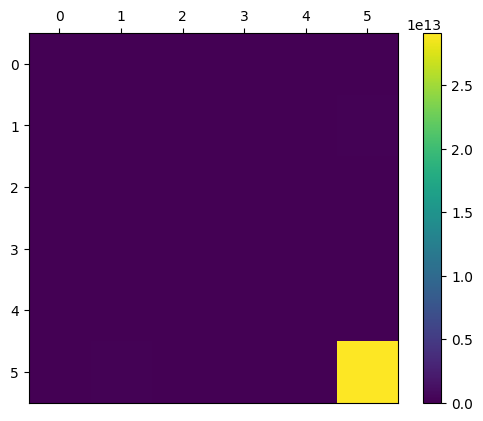

err_m_Z = 7.025716%
err_Gamma_Z = 181485943.945329%
err_a_1 = 94.803523%
err_a_2 = 167.780002%
err_a_3 = -157.486262%
err_const = -44840271.454412%


In [6]:
plt.imshow(mBW_pcov)
plt.colorbar()
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.show()

print(f"err_m_Z = {np.sqrt(mBW_pcov[0,0]) / mBW_popt[0]:%}\n"
      f"err_Gamma_Z = {np.sqrt(mBW_pcov[1,1]) / mBW_popt[1]:%}\n"
      f"err_a_1 = {np.sqrt(mBW_pcov[2,2]) / mBW_popt[2]:%}\n"
      f"err_a_2 = {np.sqrt(mBW_pcov[3,3]) / mBW_popt[3]:%}\n"
      f"err_a_3 = {np.sqrt(mBW_pcov[4,4]) / mBW_popt[4]:%}\n"
      f"err_const = {np.sqrt(mBW_pcov[5,5]) / mBW_popt[5]:%}")

These have very high error and are very sensitive to changes in the parameters. This makes it difficult to fit.
Try reducing the complexity.

$$
\mathrm{mBW_{simple}}= \mathrm{mBW}(m_{\mu\mu}; 91.1876, 2.4952, a_1, a_2, a_3) =
\dfrac{\exp(a_1 + a_2 m_{\mu\mu} + a_3 m_{\mu\mu}^2)}
      {(m_{\mu\mu} - 91.1876)^{2} + \left( \dfrac{2.4952}{2} \right)^{2}}
$$


In [7]:
def mBW_simple(m, a_1, a_2, a_3):
    # use exponents and logarithms to deal with very high numbers
    # print(a_1, a_2, a_3)
    return np.exp(a_1 + a_2*m + a_3 * m**2) / np.exp(2*np.log(m - 91.1876) + 2*np.log(2.4952 / 2))

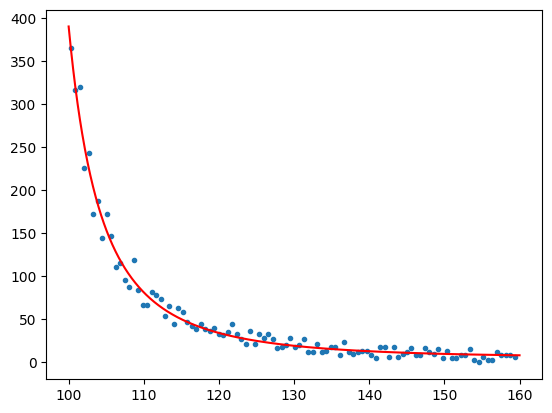

a_1 = 13.35524287576104
a_2 = -0.04489773047377457
a_3 = 0.0001897167762900822



In [8]:
# restrict range
lower_bound = 100
upper_bound = 160
restricted_simulated_background = simulated_background.remove(
    (pl.col("effective_mass") < lower_bound) | (pl.col("effective_mass") > upper_bound)
)

mBW_simple_fit_hist_data = restricted_simulated_background["effective_mass"].hist(bin_count=100)
mBW_simple_bin_width = (mBW_simple_fit_hist_data["breakpoint"][1:] - mBW_simple_fit_hist_data["breakpoint"][:-1]).mean()
mBW_simple_bin_centres = mBW_simple_fit_hist_data["breakpoint"] - (mBW_simple_bin_width / 2)

# fit the curve
mBW_simple_popt, mBW_simple_pcov = optimize.curve_fit(
    mBW_simple, mBW_simple_bin_centres, mBW_simple_fit_hist_data["count"]/mBW_simple_bin_width, p0=[10, -0.05, 0.001],
    maxfev=1000000000
)

# plot data
plt.scatter(mBW_simple_bin_centres, mBW_simple_fit_hist_data["count"]/mBW_simple_bin_width, marker=".") #width=mBW_simple_bin_width) # <- from when it was a bar plot

# plot fit
masses = np.linspace(lower_bound, upper_bound, 1000)
fit_curve_y = mBW_simple(masses, mBW_simple_popt[0], mBW_simple_popt[1], mBW_simple_popt[2])
plt.plot(masses, fit_curve_y, color="red")

plt.show()
print(f"a_1 = {mBW_simple_popt[0]}\n"
      f"a_2 = {mBW_simple_popt[1]}\n"
      f"a_3 = {mBW_simple_popt[2]}\n")

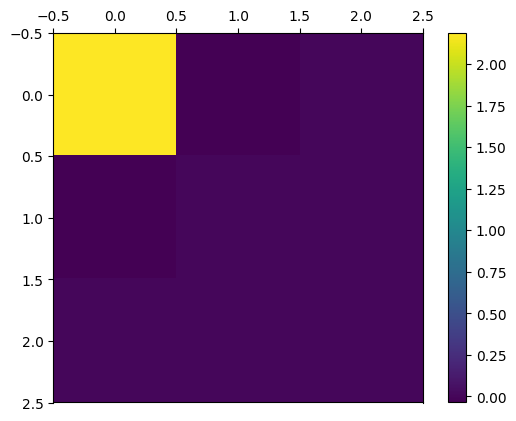

err_a_1 = 11.076647%
err_a_2 = -57.403881%
err_a_3 = 58.643784%



In [9]:
plt.imshow(mBW_simple_pcov)
plt.colorbar()
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.show()

print(f"err_a_1 = {np.sqrt(mBW_simple_pcov[0,0]) / mBW_simple_popt[0]:%}\n"
      f"err_a_2 = {np.sqrt(mBW_simple_pcov[1,1]) / mBW_simple_popt[1]:%}\n"
      f"err_a_3 = {np.sqrt(mBW_simple_pcov[2,2]) / mBW_simple_popt[2]:%}\n")

Move on to a different function.

Sum of a Breit-Wigner Function and a $\frac{1}{(m_{\mu \mu})^2}$ term to model the Z-boson and photon contributions respectively.

$$
\mathrm{BWplusPhoton}(m_{\mu \mu}; m_Z, \Gamma_Z, \lambda, \beta) =
\frac{\beta C_1 \mathrm{e}^{-\lambda m_{\mu \mu}}}{(m_{\mu\mu} - m_Z)^2 + \frac{\Gamma_Z^2}{4}}
+ \frac{(1 - \beta) C_2 \mathrm{e}^{-\lambda m_{\mu \mu}}}{(m_{\mu \mu})^2}
$$

$m_Z$, $\Gamma_Z$, $\lambda$ and $\beta$ are fitting parameters with $C_1$ and $C_2$ being constants such that the fractional terms (without the $\beta$-terms) integrate to unity within the range of integration. Another fitting parameter, `const`, which multiplies all of them is added.

In [10]:
def BWplusPhoton(m, m_Z, Gamma_Z, lambda_parameter, beta_parameter, const):

    C_1 = np.reciprocal(integrate.quad(
        lambda x: np.exp(lambda_parameter * x) * np.reciprocal(np.power(x - m_Z, 2) + Gamma_Z**2/4),
        lower_bound,
        upper_bound,
    )[0])

    C_2 = np.reciprocal(integrate.quad(
        lambda x: np.exp(lambda_parameter * x) * np.reciprocal(np.power(x, 2)),
        lower_bound,
        upper_bound
    )[0])

    return const * (
        beta_parameter *  C_1 * np.exp(lambda_parameter * m)
        * np.reciprocal(np.power(m - m_Z, 2) + Gamma_Z**2/4)
        + (1 - beta_parameter) * C_2 * np.exp(lambda_parameter * m) * np.reciprocal(np.power(m, 2))
    )

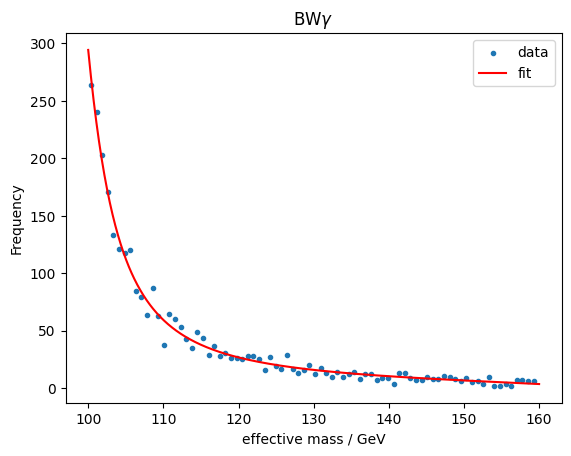

m_Z = 95.64955897116764
Gamma_Z = -7.667362219359887
lambda = 0.036152466380636634
beta = 1.2672914615449546
const = 2192.355441693166



In [11]:
# restrict range
lower_bound = 100  # these variables are hard-coded into the definition of the function to be fitted
upper_bound = 160  # these variables are hard-coded ino the definition of the function to be fitted
restricted_simulated_background = simulated_background.remove(
    (pl.col("effective_mass") < lower_bound) | (pl.col("effective_mass") > upper_bound)
)

BWplusPhoton_fit_hist_data = restricted_simulated_background["effective_mass"].hist(bin_count=80)
BWplusPhoton_bin_width = (BWplusPhoton_fit_hist_data["breakpoint"][1:] -
                          BWplusPhoton_fit_hist_data["breakpoint"][:-1]).mean()
BWplusPhoton_bin_centres = BWplusPhoton_fit_hist_data["breakpoint"] - (BWplusPhoton_bin_width / 2)

# fit the curve
BWplusPhoton_popt, BWplusPhoton_pcov = optimize.curve_fit(
    BWplusPhoton, BWplusPhoton_bin_centres, BWplusPhoton_fit_hist_data["count"],
    p0=[91.19, 7, 0.1, 9, 100],
    maxfev=1000000000
)

# plot data
plt.scatter(BWplusPhoton_bin_centres, BWplusPhoton_fit_hist_data["count"], marker=".", label="data") #width=BWplusPhoton_bin_width)

# plot fit
masses = np.linspace(lower_bound, upper_bound, 1000)
fit_curve_y = BWplusPhoton(masses, BWplusPhoton_popt[0], BWplusPhoton_popt[1], BWplusPhoton_popt[2],
                           BWplusPhoton_popt[3], BWplusPhoton_popt[4])
plt.plot(masses, fit_curve_y, color="red", label="fit")
plt.title(r"BW$\gamma$")
plt.xlabel("effective mass / GeV")
plt.ylabel("Frequency")
plt.legend()

plt.show()
print(f"m_Z = {BWplusPhoton_popt[0]}\n"
      f"Gamma_Z = {BWplusPhoton_popt[1]}\n"
      f"lambda = {BWplusPhoton_popt[2]}\n"
      f"beta = {BWplusPhoton_popt[3]}\n"
      f"const = {BWplusPhoton_popt[4]}\n")

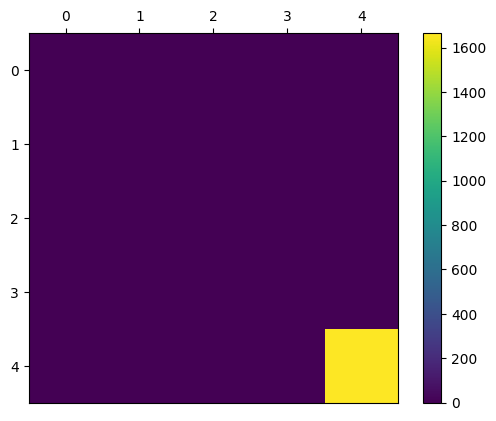

err_m_Z = 1.875597%
err_Gamma_Z = -19.512630%
err_lambda = 33.256052%
err_beta = 8.282604%
err_const = 1.860332%



In [12]:
plt.imshow(BWplusPhoton_pcov)
plt.colorbar()
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.show()

print(f"err_m_Z = {np.sqrt(BWplusPhoton_pcov[0,0]) / BWplusPhoton_popt[0]:%}\n"
      f"err_Gamma_Z = {np.sqrt(BWplusPhoton_pcov[1,1]) / BWplusPhoton_popt[1]:%}\n"
      f"err_lambda = {np.sqrt(BWplusPhoton_pcov[2,2]) / BWplusPhoton_popt[2]:%}\n"
      f"err_beta = {np.sqrt(BWplusPhoton_pcov[3,3]) / BWplusPhoton_popt[3]:%}\n"
      f"err_const = {np.sqrt(BWplusPhoton_pcov[4,4]) / BWplusPhoton_popt[4]:%}\n")

Not all fit values agree with literature values.
Move on to a different function.

Sum of a Breit-Wigner Function and a $\frac{1}{(m_{\mu \mu})^2}$ term to model the Z-boson and photon contributions respectively.
Multiplied by exponential to imitate effect of pdf.

$$
\mathrm{BWZGamma}(m_{\mu \mu}; m_Z, \Gamma_Z, \lambda, \beta) =
\beta \frac{\Gamma_Z \mathrm{e}^{-\lambda m_{\mu \mu}} }{(m_{\mu\mu} - m_Z)^2 + \frac{\Gamma_Z^2}{4}}
+
(1 - \beta) \frac{ \mathrm{e}^{-\lambda m_{\mu \mu}} }{(m_{\mu \mu})^2}
$$

$m_Z$, $\Gamma_Z$, $\lambda$ and $\beta$ are fitting parameters with $C_1$ and $C_2$ being constants such that the fractional terms (without the $\beta$-terms) integrate to unity within the range of integration.
From: https://inspirehep.net/literature/1809349

In [13]:
def BWZGamma(m, m_Z, Gamma_Z, lambda_parameter, beta_parameter, const):
    return const * (
        beta_parameter * Gamma_Z * np.exp(-lambda_parameter * m)
        * np.reciprocal(np.power(m - m_Z, 2) + Gamma_Z**2/4)
        + (1 - beta_parameter) * np.exp(-lambda_parameter * m) * np.reciprocal(np.power(m, 2))
    )

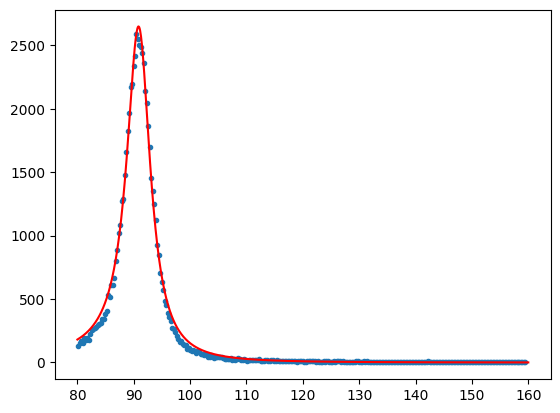

m_Z = 90.93017890385784
Gamma_Z = 5.09324462040944
lambda = 0.026255054459220287
beta = 567.6213835241327
const = 2192.355441693166



In [18]:
# restrict range
lower_bound = 80
upper_bound = 160
restricted_simulated_background = simulated_background.remove(
    (pl.col("effective_mass") < lower_bound) | (pl.col("effective_mass") > upper_bound)
)

BWZGamma_fit_hist_data = restricted_simulated_background["effective_mass"].hist(bin_count=300)
BWZGamma_bin_width = (BWZGamma_fit_hist_data["breakpoint"][1:] -
                          BWZGamma_fit_hist_data["breakpoint"][:-1]).mean()
BWZGamma_bin_centres = BWZGamma_fit_hist_data["breakpoint"] - (BWZGamma_bin_width / 2)

# fit the curve
BWZGamma_popt, BWZGamma_pcov = optimize.curve_fit(
    BWZGamma, BWZGamma_bin_centres, BWZGamma_fit_hist_data["count"],
    p0=[91.19, 7, 0.1, 500, 1000],
    maxfev=1000000000
)

# plot data
plt.scatter(BWZGamma_bin_centres, BWZGamma_fit_hist_data["count"], marker=".") #width=BWZGamma_bin_width)

# plot fit
masses = np.linspace(lower_bound, upper_bound, 1000)
fit_curve_y = BWZGamma(masses, BWZGamma_popt[0], BWZGamma_popt[1], BWZGamma_popt[2],
                           BWZGamma_popt[3], BWZGamma_popt[4])
plt.plot(masses, fit_curve_y, color="red")


plt.show()
print(f"m_Z = {BWZGamma_popt[0]}\n"
      f"Gamma_Z = {BWZGamma_popt[1]}\n"
      f"lambda = {BWZGamma_popt[2]}\n"
      f"beta = {BWZGamma_popt[3]}\n"
      f"const = {BWplusPhoton_popt[4]}\n")

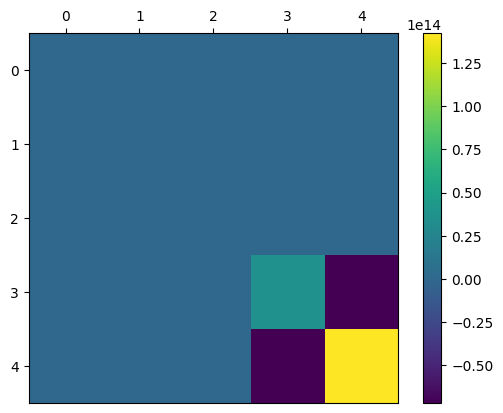

err_m_Z = 5.414964%
err_Gamma_Z = 104475.070310%
err_lambda = -109.326346%
err_beta = 7887747.397069%
err_const = 543977.986508%



In [15]:
plt.imshow(BWZGamma_pcov)
plt.colorbar()
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.show()

print(f"err_m_Z = {np.sqrt(BWZGamma_pcov[0,0]) / BWZGamma_popt[0]:%}\n"
      f"err_Gamma_Z = {np.sqrt(BWZGamma_pcov[1,1]) / BWZGamma_popt[1]:%}\n"
      f"err_lambda = {np.sqrt(BWZGamma_pcov[2,2]) / BWZGamma_popt[2]:%}\n"
      f"err_beta = {np.sqrt(BWZGamma_pcov[3,3]) / BWZGamma_popt[3]:%}\n"
      f"err_const = {np.sqrt(BWZGamma_pcov[4,4]) / BWplusPhoton_popt[4]:%}\n")

Errors are horrible.
\
BWplusPhoton function has the lowest errors and values close to literature, so choose that.